# Auto Scout Project

**Author:** Mark Joslin

**GitHub:** [link](https://github.com/mjoslin-ai/Magnimind-Project-Auto-Scout)

## Table of Contents

* Objective
* Libraries
* Helper Functions
* Import Data
* All Features
* Reduced Features
* Export Best Model

## Objective

The objective of this notebook is to build, tune, evaluate, and compare machine learning regression models to **predict the price** of used cars in the Auto Scout dataset.

Using the fully cleaned, preprocessed, and feature-engineered dataset produced in the previous stages (data cleaning, missing value analysis, outlier handling, and dummy variable generation), we now have a structured numeric dataset containing **15,918 rows and 158 columns**, with all features converted to `float` or `integer` types — fully compatible with machine learning algorithms.

In this notebook, we test several regression models with Optuna hyperparameter tuning, select the best performing model, analyze variable importance, and retrain the top model on a reduced feature set to improve interpretability and computational efficiency.

This notebook completes the end-to-end Auto Scout project workflow, from raw, inconsistent data to a production ready predictive model capable of accurately estimating car prices based on vehicle characteristics.

## Libraries

In [12]:
# Standard Library
import os

# Data Science & Visualization
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import shap

# System / Utilities
import joblib

# Scikit-learn
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import  StandardScaler
from sklearn.svm import SVR

# Advanced ML Frameworks & Hyperparameter Optimization
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import optuna
from xgboost import XGBRegressor

## Helper Functions

In [13]:
def tune_and_fit_model(model, param_space_fn, X, y, cv=5, n_trials=20, n_jobs=8, seed=42):
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    # Check if a pipeline is passed to prefix parameters correctly
    if isinstance(model, Pipeline):
        model_step_name = model.steps[-1][0]
        prefix = f'{model_step_name}__'
    else:
        prefix = ''

    def objective(trial):
        params = param_space_fn(trial)
        
        # Apply prefix if it's a pipeline, otherwise apply directly
        if prefix:
            prefixed_params = {f'{prefix}{k}': v for k, v in params.items()}
            model.set_params(**prefixed_params)
        else:
            model.set_params(**params)
            
        try:
            return cross_val_score(model, X, y, cv=cv, scoring='r2', n_jobs=n_jobs).mean()
        except Exception as e:
            print(f"Trial {trial.number} failed: {str(e)[:100]}")
            return float("-inf")

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials)

    print(f"Best Validation R2 Score: {study.best_value:.4f}")
    print("\nBest Hyperparameters:")
    for k, v in study.best_params.items():
        print(f"{k}: {round(v, 4) if isinstance(v, (int, float)) else v}")

    # Fit the best model on the full training data
    if prefix:
        best_params = {f'{prefix}{k}': v for k, v in study.best_params.items()}
        model.set_params(**best_params).fit(X, y)
    else:
        model.set_params(**study.best_params).fit(X, y)

    return model, study

In [14]:
def get_model_name(model):
    """
    Helper to extract the class name of the final estimator.
    """
    return type(model._final_estimator).__name__ if hasattr(model, 'steps') else type(model).__name__

In [31]:
def evaluate_model(model, X_train, y_train, X_test, y_test, filepath="model_results.csv"):
    """
    Evaluate model and log results to CSV.
    """
    name = get_model_name(model)
    num_features = X_train.shape[1]
   
    # Calculate Metrics
    train_r2 = round(r2_score(y_train, model.predict(X_train)), 4)
    test_r2 = round(r2_score(y_test, model.predict(X_test)), 4)
    test_mae = round(mean_absolute_error(y_test, model.predict(X_test)), 4)
    test_rmse = round(root_mean_squared_error(y_test, model.predict(X_test)), 4)
    test_mape = round(mean_absolute_percentage_error(y_test, model.predict(X_test)) * 100, 4)
    
    # Store results in a dictionary to return directly
    result_dict = {
        "model": name,
        "features": num_features,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_mape": test_mape
    }
    
    # Log results to CSV
    new_data = pd.DataFrame([result_dict])
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        df = pd.concat([df, new_data], ignore_index=True)
    else:
        df = new_data
    
    # Keep only the most recent run for a specific model and feature count combination
    df = df.drop_duplicates(subset=['model', 'features'], keep='last')
    df.to_csv(filepath, index=False)
   
    print(f"Logged {name} ({num_features} features) to {filepath}")
    return result_dict

In [16]:
def plot_diagnostics(model, X_test, y_test):
    name = get_model_name(model)
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f"Diagnostic Report: {name}", fontsize=16, fontweight='bold')

    # Plot 1: Predicted vs Actual
    sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], alpha=0.5)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_title("Predicted vs. Actual")

    # Plot 2: Residuals
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], alpha=0.5)
    axes[1].axhline(0, color='r', linestyle='--', lw=2)
    axes[1].set_title("Residuals vs. Predicted")

    plt.tight_layout()
    plt.show()

In [17]:
def model_results(model, X_train, y_train, X_test, y_test, filepath="model_results.csv"):
    """
    One-call solution: plot diagnostics + evaluate + print results
    """
    plot_diagnostics(model, X_test, y_test)
    result_dict = evaluate_model(model, X_train, y_train, X_test, y_test, filepath)
    
    # Print the current run's metrics cleanly as a Pandas Series
    print(pd.Series(result_dict))

In [18]:
def get_pipeline_importance(model, X_data, feature_names=None):
    """
    Accepts an in-memory model/pipeline and calculates feature importance using SHAP.
    """
    # Extract the fitted regressor
    regressor = model._final_estimator if hasattr(model, 'steps') else model
    
    # Transform the input data if there are preprocessing steps
    if hasattr(model, 'steps') and len(model.steps) > 1:
        X_transformed = model[:-1].transform(X_data)
    else:
        X_transformed = X_data

    try:
        explainer = shap.TreeExplainer(regressor)
        shap_values = explainer.shap_values(X_transformed)

        # Calculate Global Importance 
        if isinstance(shap_values, list): 
            mean_shap = np.abs(shap_values[0]).mean(axis=0)
        else:
            mean_shap = np.abs(shap_values).mean(axis=0)

        if feature_names is None:
            feature_names = X_data.columns if hasattr(X_data, 'columns') else [f"Feature_{i}" for i in range(len(mean_shap))]

        df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': mean_shap
        })

        df = df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
        df['Cumulative_Importance'] = df['Importance'].cumsum() / df['Importance'].sum()

        return df

    except Exception as e:
        return f"SHAP extraction error: {str(e)}"

In [33]:
def export_model(model, X_train, model_dir="saved_models", custom_name=None):
    """
    Exports a trained model to a specified directory.
    """
    os.makedirs(model_dir, exist_ok=True)
    
    # Auto-generate a name if one isn't provided
    if custom_name is None:
        name = get_model_name(model)
        num_features = X_train.shape[1]
        filename = f"{name}_{num_features}_features.joblib"
    else:
        filename = custom_name
        if not filename.endswith('.joblib'):
            filename += '.joblib'
            
    filepath = os.path.join(model_dir, filename)
    
    # Compress=3 provides a good balance between file size and save/load speed
    joblib.dump(model, filepath, compress=3)
    print(f"Model successfully saved to {filepath}")

## Import Data

In [19]:
df_org = pd.read_csv("data/cleaned_data.csv")
df = df_org.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15918 entries, 0 to 15917
Columns: 158 entries, price to entertainment_media_usb
dtypes: float64(17), int64(141)
memory usage: 19.2 MB


## All Features

In [ ]:
# Split data
x = df.drop('price', axis=1)
y = df['price']
(X_train, X_test), (y_train, y_test) = train_test_split(x, y, test_size=0.2, random_state=42)

### Ordinary Least Squares

Best Validation R2 Score: 0.8907
Best Hyperparameters: {'ols__fit_intercept': True}


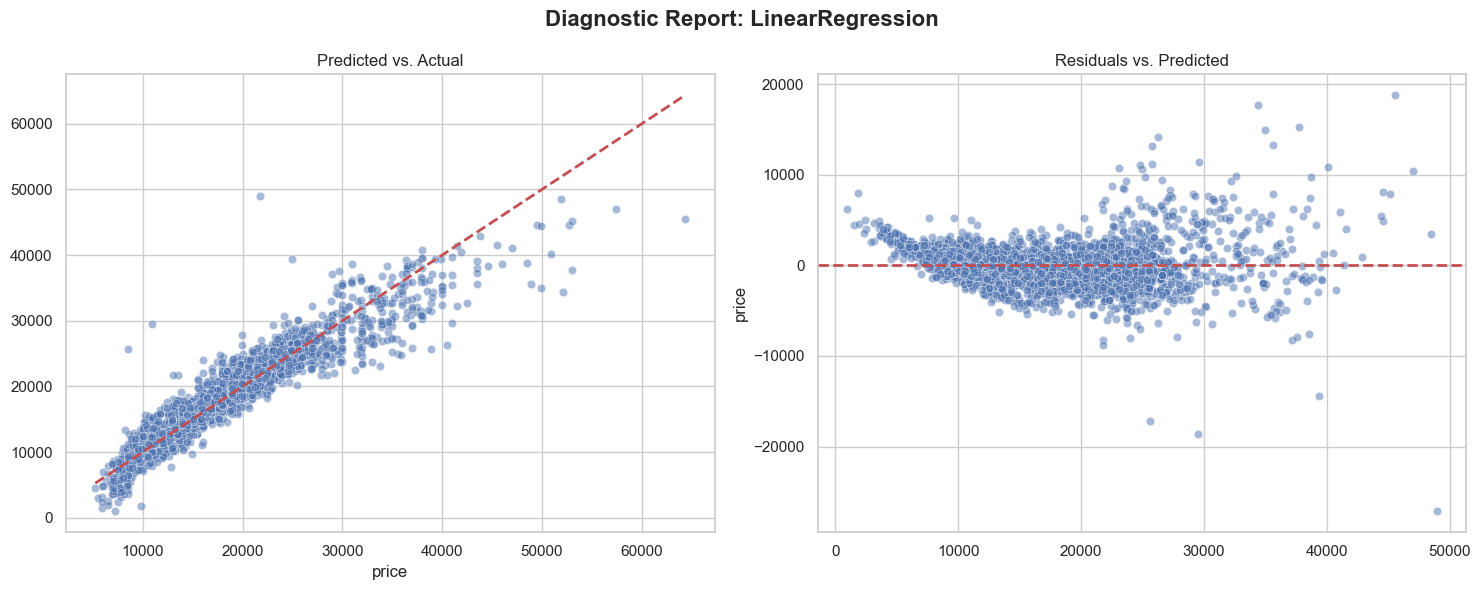

Saved model to saved_models\LinearRegression_157_features.joblib
Logged LinearRegression (157 features) to model_results.csv
model        LinearRegression
features                  157
train_r2                0.896
test_r2                0.8903
test_mae            1660.1408
test_rmse           2432.4521
test_mape             10.0941
dtype: object


In [21]:
ols_pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('ols', LinearRegression())
])

# Simple Grid Search instead of Optuna
params = {'ols__fit_intercept': [True, False]}
grid = GridSearchCV(ols_pipe, params, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best Validation R2 Score: {grid.best_score_:.4f}")
print(f"Best Hyperparameters: {grid.best_params_}")

ols_model = grid.best_estimator_
model_results(ols_model, X_train, y_train, X_test, y_test)

No evidence of overfitting, thus Ridge and Lasso regression will no be used.

### Random Forest

Best Validation R2 Score: 0.9476

Best Hyperparameters:
n_estimators: 736
max_features: 0.4166
max_depth: 17
min_samples_split: 2
min_samples_leaf: 3
max_samples: 0.6584


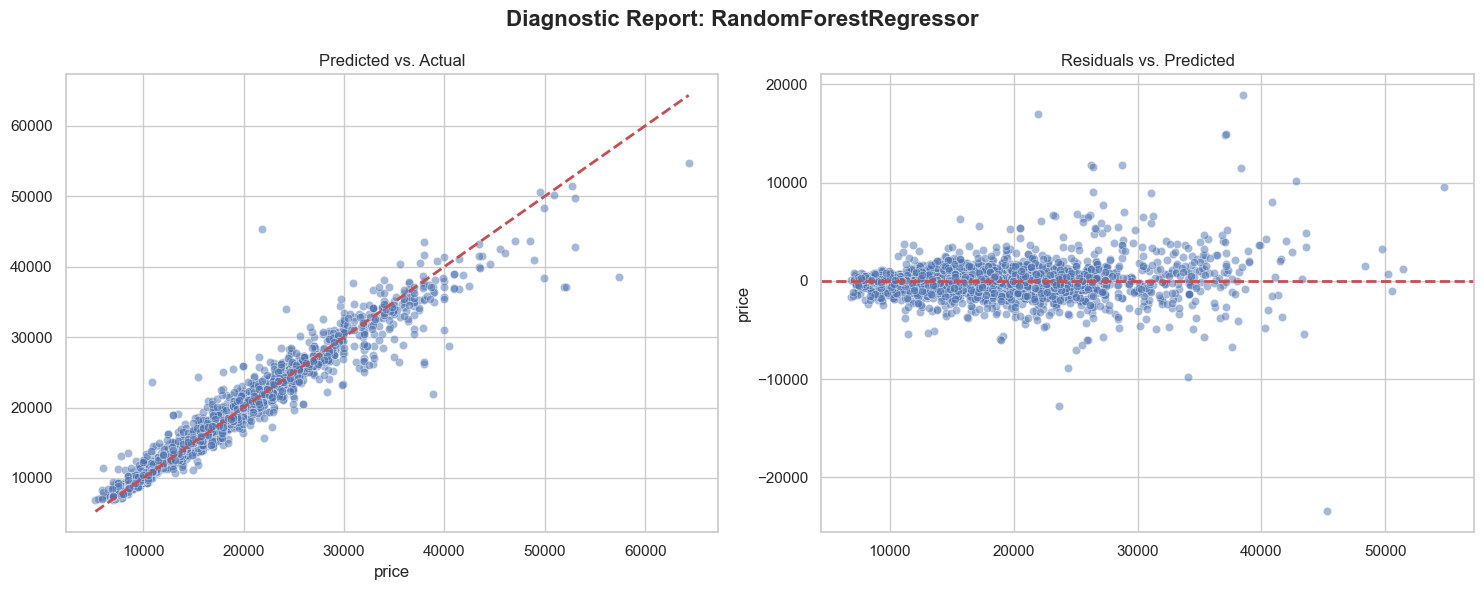

Saved model to saved_models\RandomForestRegressor_157_features.joblib
Logged RandomForestRegressor (157 features) to model_results.csv
model        RandomForestRegressor
features                       157
train_r2                    0.9763
test_r2                     0.9509
test_mae                  908.7064
test_rmse                1627.8046
test_mape                   5.0151
dtype: object


In [22]:
rf_model = RandomForestRegressor(random_state=42)

def rf_space(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_features': trial.suggest_float('max_features', 0.1, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_samples': trial.suggest_float('max_samples', 0.5, 1.0)
    }

rf_model, rf_study = tune_and_fit_model(rf_model, rf_space, X_train, y_train)

model_results(rf_model, X_train, y_train, X_test, y_test)

### XGBoost

Best Validation R2 Score: 0.9586

Best Hyperparameters:
learning_rate: 0.0391
n_estimators: 683
max_depth: 8
min_child_weight: 3
subsample: 0.7344
colsample_bytree: 0.6879


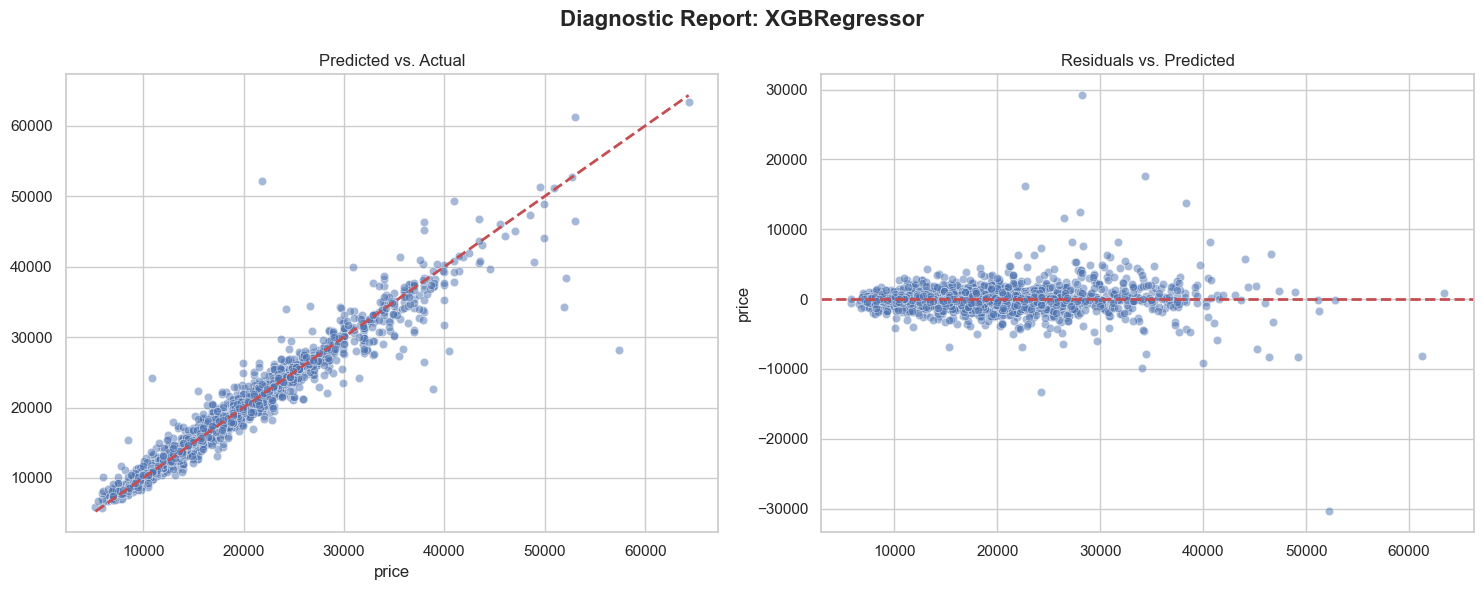

Saved model to saved_models\XGBRegressor_157_features.joblib
Logged XGBRegressor (157 features) to model_results.csv
model        XGBRegressor
features              157
train_r2           0.9962
test_r2            0.9534
test_mae          811.238
test_rmse       1585.3753
test_mape          4.4853
dtype: object


In [ ]:
xgb_model = XGBRegressor(random_state=42)

def xgb_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }

xgb_model, xgb_study = tune_and_fit_model(xgb_model, xgb_space, X_train, y_train)

model_results(xgb_model, X_train, y_train, X_test, y_test)

### Gradient Boosting

Best Validation R2 Score: 0.9599

Best Hyperparameters:
learning_rate: 0.0256
n_estimators: 790
max_depth: 10
subsample: 0.7241
max_features: 0.3262
min_samples_split: 9
min_samples_leaf: 9


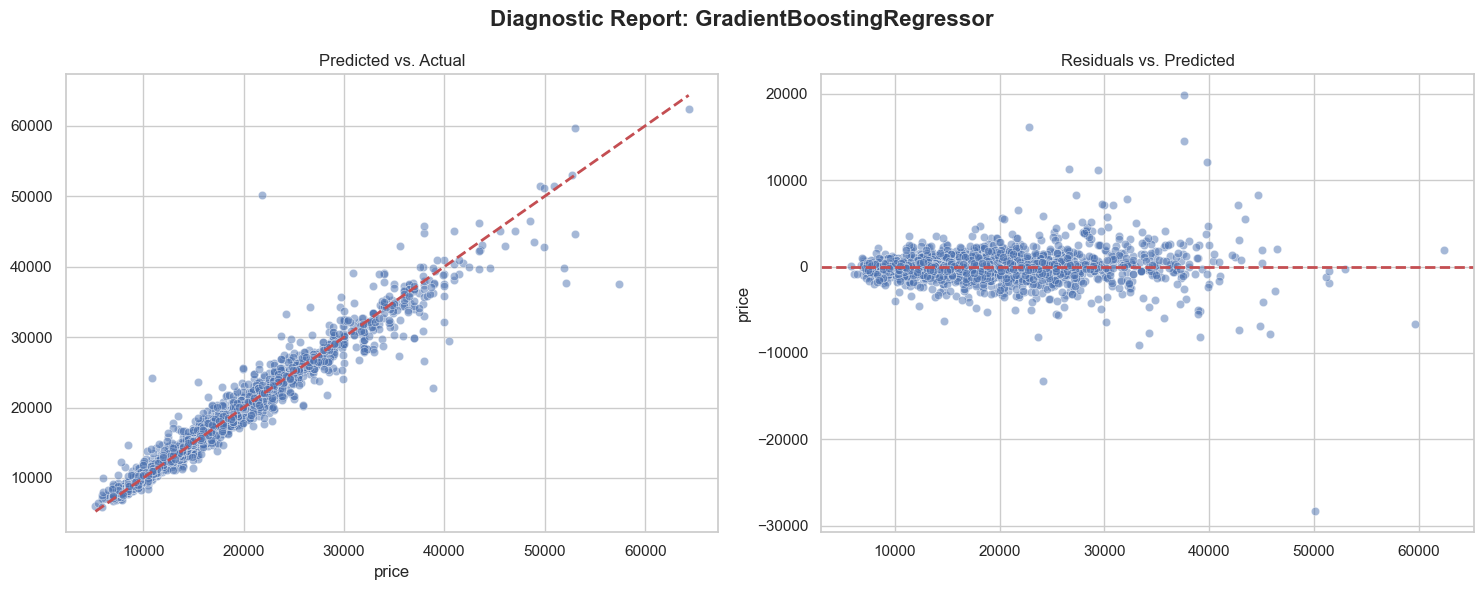

Saved model to saved_models\GradientBoostingRegressor_157_features.joblib
Logged GradientBoostingRegressor (157 features) to model_results.csv
model        GradientBoostingRegressor
features                           157
train_r2                        0.9941
test_r2                         0.9577
test_mae                      816.5701
test_rmse                    1510.6695
test_mape                       4.5325
dtype: object


In [ ]:
gb_model = GradientBoostingRegressor(random_state=42)

def gb_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_float('max_features', 0.1, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
    }

gb_model, gb_study = tune_and_fit_model(gb_model, gb_space, X_train, y_train)

model_results(gb_model, X_train, y_train, X_test, y_test)

### LightGBM

Best Validation R2 Score: 0.9584

Best Hyperparameters:
learning_rate: 0.1069
num_leaves: 90
n_estimators: 822
max_depth: 12
min_child_samples: 78
colsample_bytree: 0.6089


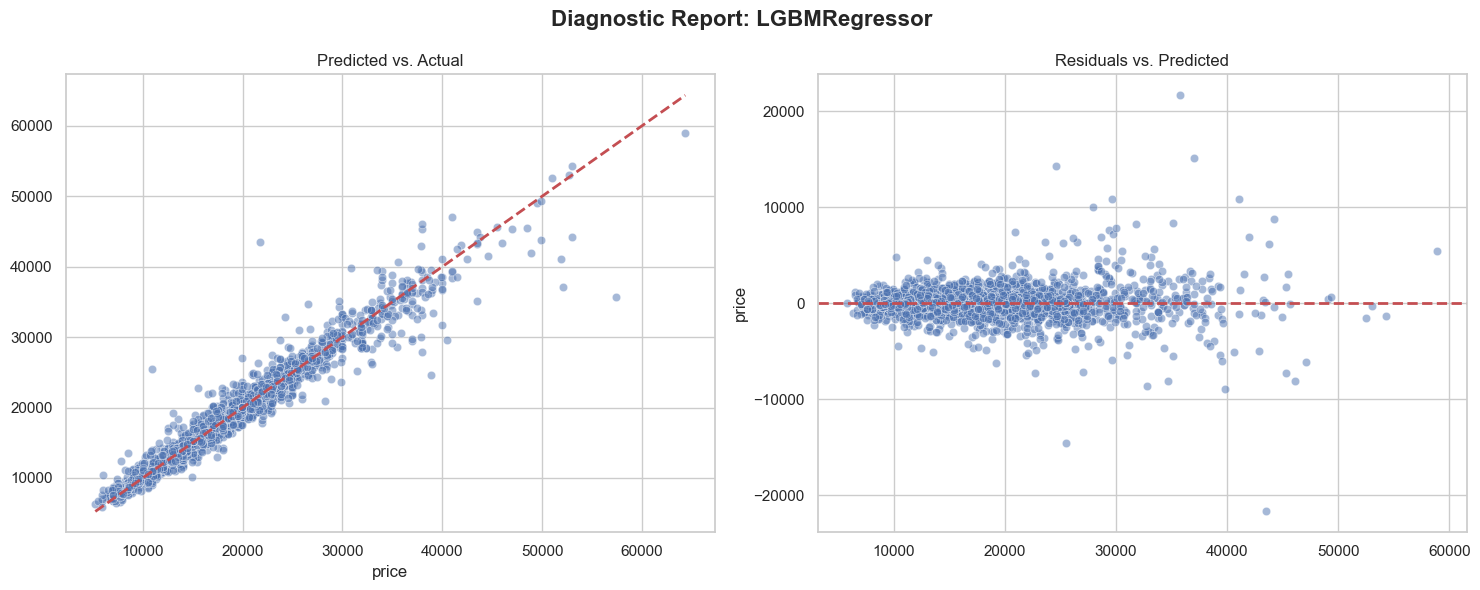

Saved model to saved_models\LGBMRegressor_157_features.joblib
Logged LGBMRegressor (157 features) to model_results.csv
model        LGBMRegressor
features               157
train_r2            0.9936
test_r2             0.9564
test_mae          861.4685
test_rmse        1533.8636
test_mape           4.7866
dtype: object


In [ ]:
lgbm_model = LGBMRegressor(random_state=42, verbosity=-1)

def lgbm_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }

lgbm_model, lgbm_study = tune_and_fit_model(lgbm_model, lgbm_space, X_train, y_train)

model_results(lgbm_model, X_train, y_train, X_test, y_test)

### Catboost

Best Validation R2 Score: 0.9587

Best Hyperparameters:
learning_rate: 0.1317
iterations: 540
depth: 9
l2_leaf_reg: 0.1428
random_strength: 0.0008
bagging_temperature: 0.0017
border_count: 108


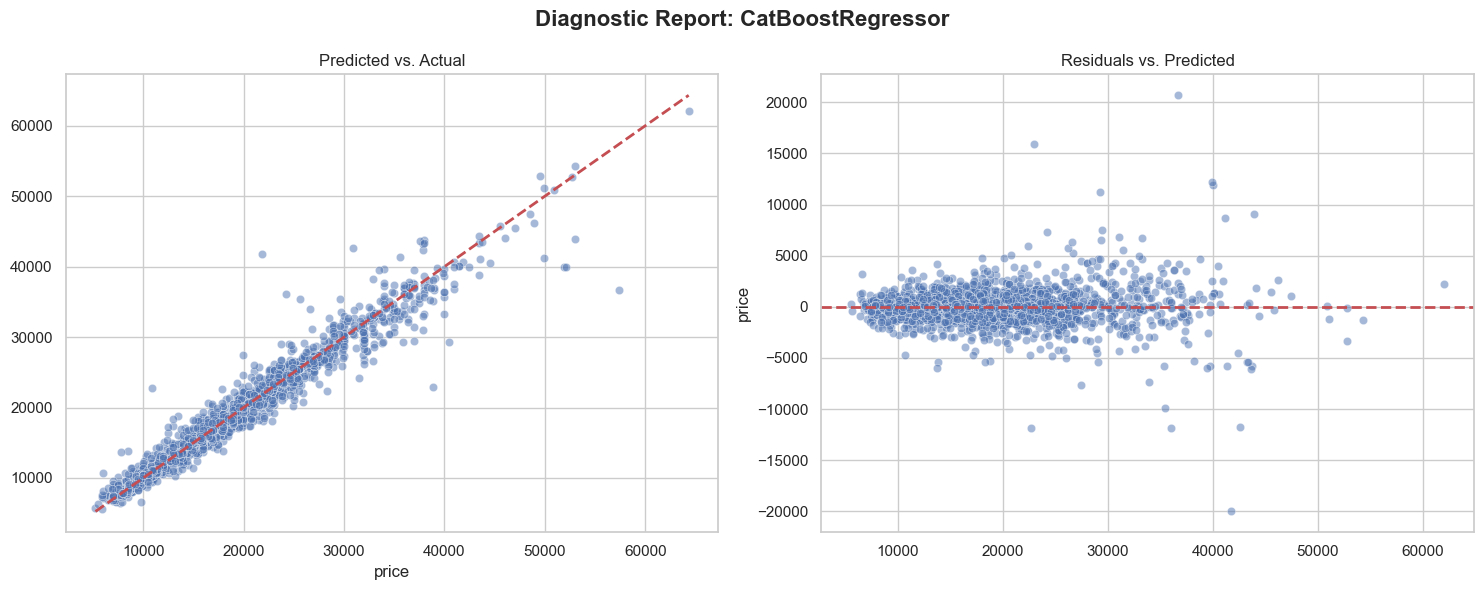

Saved model to saved_models\CatBoostRegressor_157_features.joblib
Logged CatBoostRegressor (157 features) to model_results.csv
model        CatBoostRegressor
features                   157
train_r2                0.9976
test_r2                 0.9594
test_mae              826.6308
test_rmse            1478.6383
test_mape               4.6141
dtype: object


In [ ]:
cat_model = CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False)

def cat_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 255)
    }

cat_model, cat_study = tune_and_fit_model(cat_model, cat_space, X_train, y_train)

model_results(cat_model, X_train, y_train, X_test, y_test)

### SVR

Best Validation R2 Score: 0.8807

Best Hyperparameters:
C: 93.6681
epsilon: 0.9607
kernel: linear
gamma: auto


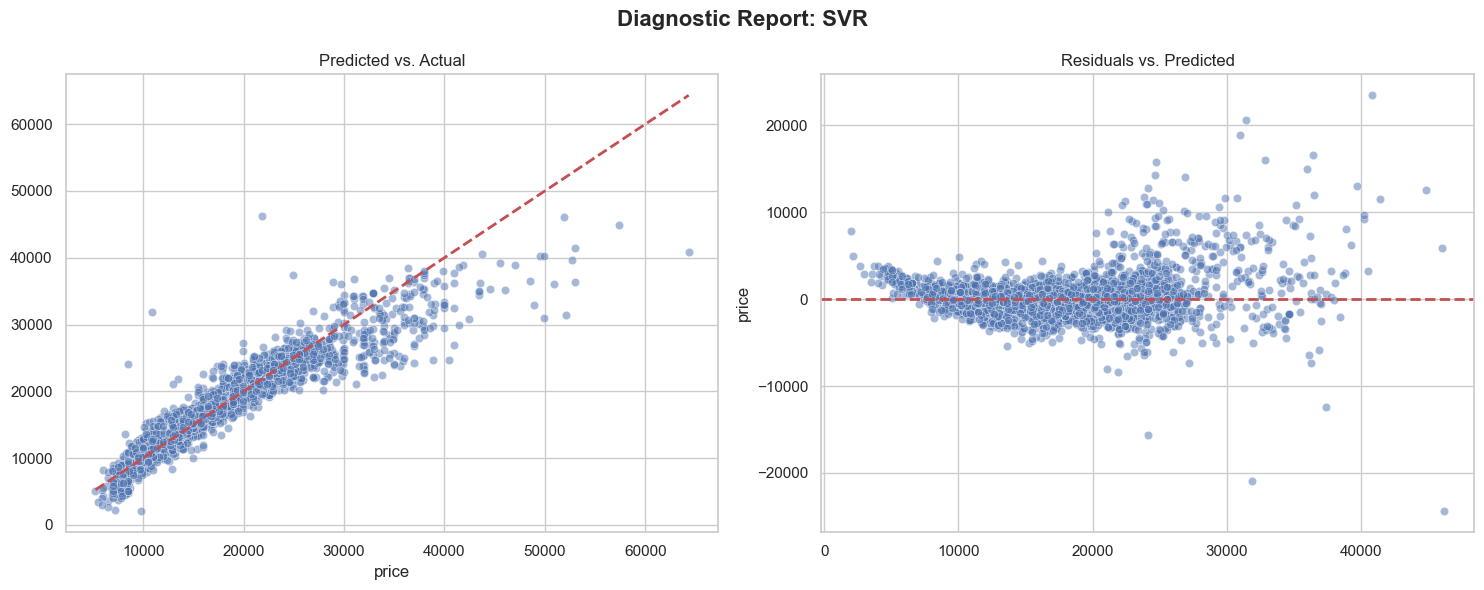

Saved model to saved_models\SVR_157_features.joblib
Logged SVR (157 features) to model_results.csv
model              SVR
features           157
train_r2        0.8845
test_r2         0.8813
test_mae     1567.9869
test_rmse    2529.9288
test_mape       8.9773
dtype: object


In [ ]:
svr_pipe = Pipeline([ 
    ('scaler', StandardScaler()), 
    ('svr', SVR()) 
])

def svr_space(trial):
    return {
        'C': trial.suggest_float('C', 0.1, 100, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.01, 10, log=True),
        'kernel': trial.suggest_categorical('kernel', ['rbf', 'linear']),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto'])
    }

svr_model, svr_study = tune_and_fit_model(svr_pipe, svr_space, X_train, y_train)

model_results(svr_model, X_train, y_train, X_test, y_test)

### Performance Table

In [28]:
results = pd.read_csv('model_results.csv')

results[results['features'] == X_test.shape[1]].sort_values(by='test_r2', ascending=False)

,model,features,train_r2,test_r2,test_mae,test_rmse,test_mape
8,CatBoostRegressor,157,0.9976,0.9594,826.6308,1478.6383,4.6141
6,GradientBoostingRegressor,157,0.9941,0.9577,816.5701,1510.6695,4.5325
7,LGBMRegressor,157,0.9936,0.9564,861.4685,1533.8636,4.7866
5,XGBRegressor,157,0.9962,0.9534,811.2380,1585.3753,4.4853
4,RandomForestRegressor,157,0.9763,0.9509,908.7064,1627.8046,5.0151
3,LinearRegression,157,0.8960,0.8903,1660.1408,2432.4521,10.0941
9,SVR,157,0.8845,0.8813,1567.9869,2529.9288,8.9773


## Reduced Features

Top three models

### Catboost

In [34]:
# CatBoost
cat_importance = get_pipeline_importance(cat_model, X_test)
cat_importance.head(13)

,Feature,Importance,Cumulative_Importance
0,age_years,1763.953341,0.139415
1,hp_kw,1717.763502,0.275179
2,km,1038.803979,0.357282
3,gearing_type_manual,978.503056,0.434618
4,make_model_audi_a3,798.027613,0.497691
5,gears,487.511524,0.536222
6,make_model_renault_espace,422.968951,0.569651
7,weight_kg,350.834537,0.597380
8,make_model_renault_clio,307.251023,0.621663
9,make_model_opel_insignia,275.594039,0.643445


In [35]:
top_cat_features = cat_importance[cat_importance['Cumulative_Importance'] <= 0.60]['Feature'].tolist()

X_train_cat = X_train[top_cat_features]
X_test_cat = X_test[top_cat_features]

Best Validation R2 Score: 0.9587

Best Hyperparameters:
learning_rate: 0.1317
iterations: 540
depth: 9
l2_leaf_reg: 0.1428
random_strength: 0.0008
bagging_temperature: 0.0017
border_count: 108


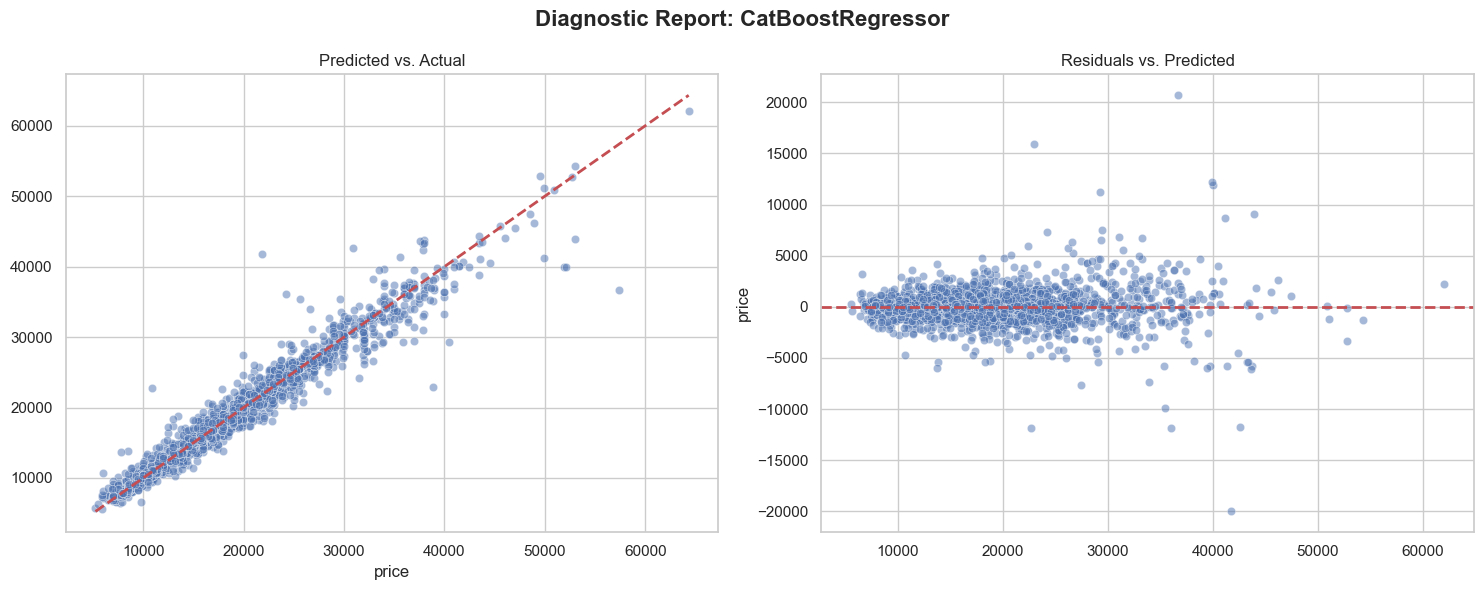

Logged CatBoostRegressor (157 features) to model_results.csv
model        CatBoostRegressor
features                   157
train_r2                0.9976
test_r2                 0.9594
test_mae              826.6308
test_rmse            1478.6383
test_mape               4.6141
dtype: object


In [36]:
cat_model = CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False)

def cat_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 255)
    }

cat_model, cat_study = tune_and_fit_model(cat_model, cat_space, X_train, y_train)

model_results(cat_model, X_train, y_train, X_test, y_test)

### LightGBM	

In [37]:
lgbm_importance = get_pipeline_importance(lgbm_model, X_test).head(12)
lgbm_importance

,Feature,Importance,Cumulative_Importance
0,hp_kw,2222.588637,0.170362
1,age_years,1574.782022,0.291070
2,km,1071.970995,0.373236
3,gearing_type_manual,703.837792,0.427186
4,make_model_renault_espace,600.910259,0.473246
5,make_model_audi_a3,519.405641,0.513058
6,gears,485.943395,0.550306
7,make_model_opel_corsa,306.889010,0.573829
8,make_model_opel_astra,275.122431,0.594917
9,make_model_opel_insignia,245.592732,0.613742


In [38]:
top_lgbm_features = lgbm_importance[lgbm_importance['Cumulative_Importance'] <= 0.60]['Feature'].tolist()

X_train_lgbm = X_train[top_lgbm_features]
X_test_lgbm = X_test[top_lgbm_features]

Best Validation R2 Score: 0.9584

Best Hyperparameters:
learning_rate: 0.1069
num_leaves: 90
n_estimators: 822
max_depth: 12
min_child_samples: 78
colsample_bytree: 0.6089


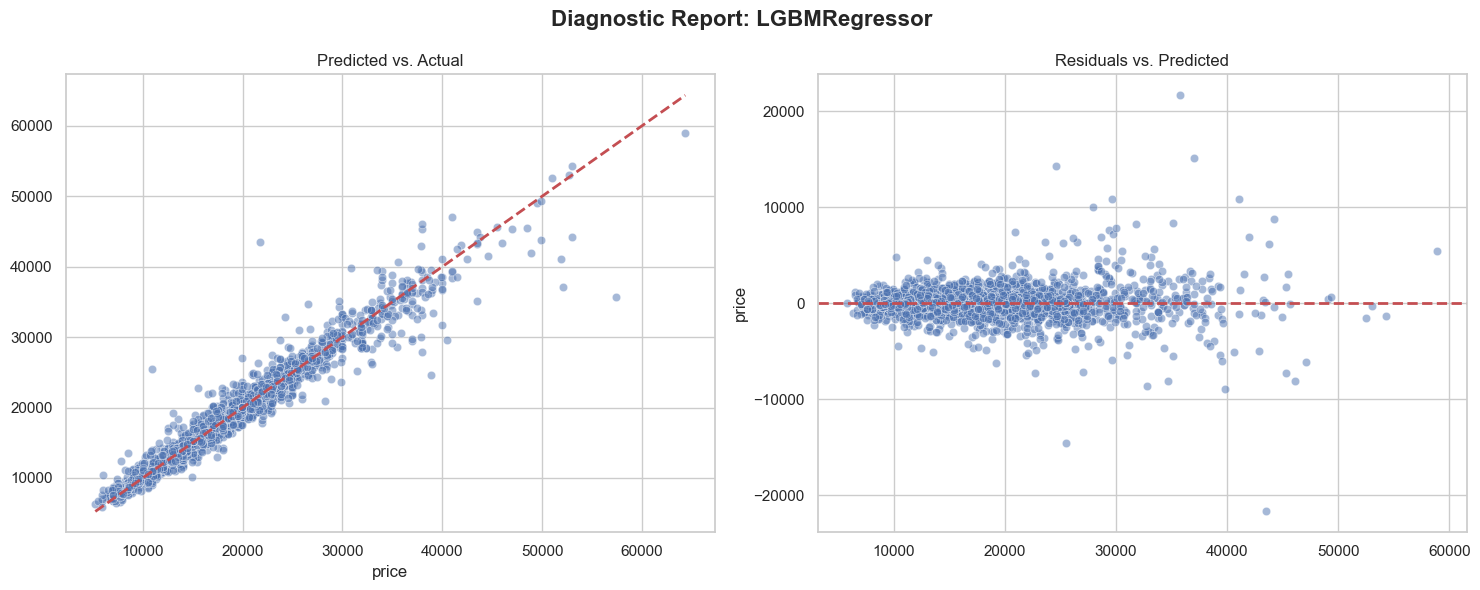

Logged LGBMRegressor (157 features) to model_results.csv
model        LGBMRegressor
features               157
train_r2            0.9936
test_r2             0.9564
test_mae          861.4685
test_rmse        1533.8636
test_mape           4.7866
dtype: object


In [39]:
lgbm_model = LGBMRegressor(random_state=42, verbosity=-1)

def lgbm_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }

lgbm_model, lgbm_study = tune_and_fit_model(lgbm_model, lgbm_space, X_train, y_train)

model_results(lgbm_model, X_train, y_train, X_test, y_test)

### Gradient Boosting

In [40]:
gb_importance = get_pipeline_importance(gb_model, X_test).head(12)
gb_importance

,Feature,Importance,Cumulative_Importance
0,hp_kw,2026.423324,0.168452
1,age_years,1511.161693,0.294071
2,km,950.786454,0.373108
3,gearing_type_manual,822.766226,0.441503
4,gears,727.587125,0.501986
5,make_model_audi_a3,457.578111,0.540023
6,make_model_renault_espace,414.441893,0.574475
7,weight_kg,361.510378,0.604526
8,next_inspection_yyyymm,305.429233,0.629916
9,make_model_opel_astra,299.967341,0.654851


In [41]:
top_gb_features = gb_importance[gb_importance['Cumulative_Importance'] <= 0.60]['Feature'].tolist()

X_train_gb = X_train[top_gb_features]
X_test_gb = X_test[top_gb_features]

Best Validation R2 Score: 0.9599

Best Hyperparameters:
learning_rate: 0.0256
n_estimators: 790
max_depth: 10
subsample: 0.7241
max_features: 0.3262
min_samples_split: 9
min_samples_leaf: 9


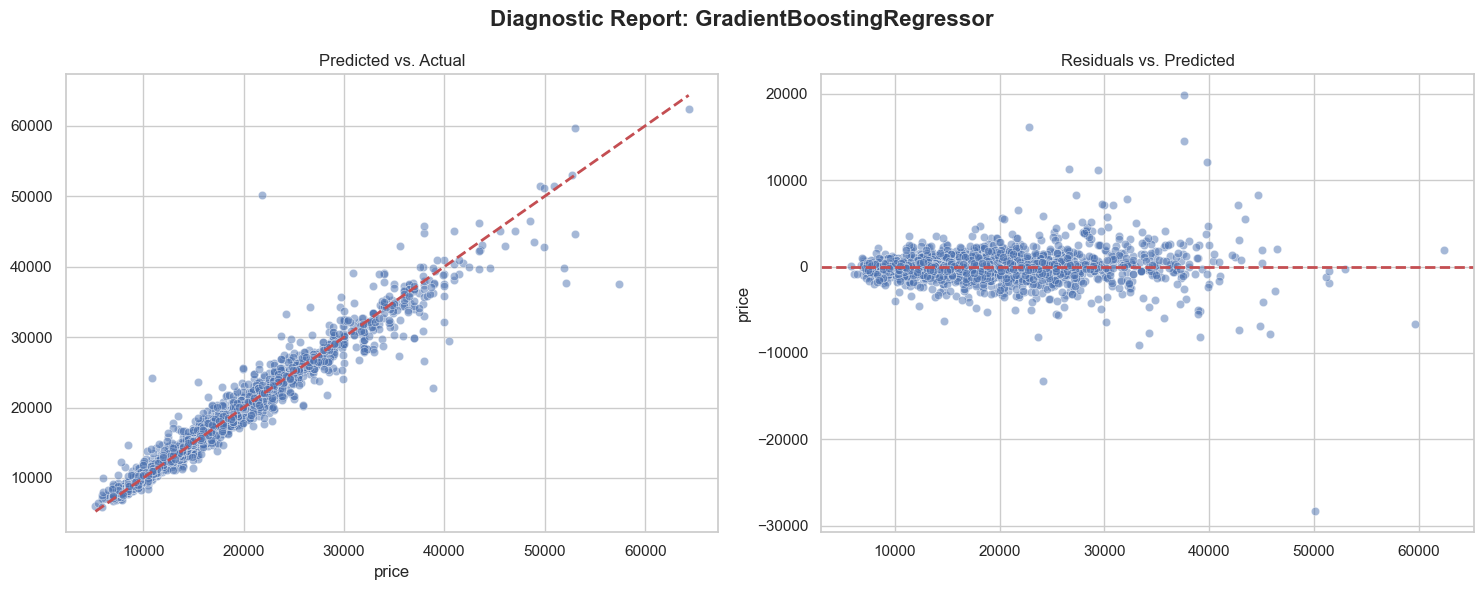

Logged GradientBoostingRegressor (157 features) to model_results.csv
model        GradientBoostingRegressor
features                           157
train_r2                        0.9941
test_r2                         0.9577
test_mae                      816.5701
test_rmse                    1510.6695
test_mape                       4.5325
dtype: object


In [42]:
gb_model = GradientBoostingRegressor(random_state=42)

def gb_space(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_float('max_features', 0.1, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
    }

gb_model, gb_study = tune_and_fit_model(gb_model, gb_space, X_train, y_train)

model_results(gb_model, X_train, y_train, X_test, y_test)

### Performance Table

In [44]:
results = pd.read_csv('model_results.csv')

results.sort_values(by='test_r2', ascending=False)

,model,features,train_r2,test_r2,test_mae,test_rmse,test_mape
7,CatBoostRegressor,157,0.9976,0.9594,826.6308,1478.6383,4.6141
9,GradientBoostingRegressor,157,0.9941,0.9577,816.5701,1510.6695,4.5325
8,LGBMRegressor,157,0.9936,0.9564,861.4685,1533.8636,4.7866
5,XGBRegressor,157,0.9962,0.9534,811.2380,1585.3753,4.4853
4,RandomForestRegressor,157,0.9763,0.9509,908.7064,1627.8046,5.0151
0,CatBoostRegressor,8,0.9676,0.9207,1156.3256,2068.1005,6.3576
1,LGBMRegressor,9,0.9517,0.9124,1201.8871,2173.2348,6.5709
2,GradientBoostingRegressor,7,0.9397,0.9080,1360.4813,2226.5265,7.8130
3,LinearRegression,157,0.8960,0.8903,1660.1408,2432.4521,10.0941
6,SVR,157,0.8845,0.8813,1567.9869,2529.9288,8.9773


## Export Best Model

In [45]:
export_model(cat_model, X_train_cat)

Model successfully saved to saved_models\CatBoostRegressor_8_features.joblib
